# Urban Heat Island Analysis and Heat Risk Prediction in Lucknow Using Remote Sensing and Machine Learning

In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load Temperature Data
Here, we read the Lucknow temperature map and get a quick overview of the data, including its dimensions and temperature range.

In [3]:
lst_path = r"Lucknow_LST.tif"
with rasterio.open(lst_path) as src:
    lst = src.read(1)
print("Shape:", lst.shape)
print("Minimum:", np.nanmin(lst))
print("Maximum:", np.nanmax(lst))

Shape: (1109, 1327)
Minimum: 22.715483360000007
Maximum: 33.06524792000005


# Visualizing Temperature Distribution
This plot shows how temperature varies across Lucknow. Different colors represent different temperature levels, making it easier to identify hotter and cooler areas.

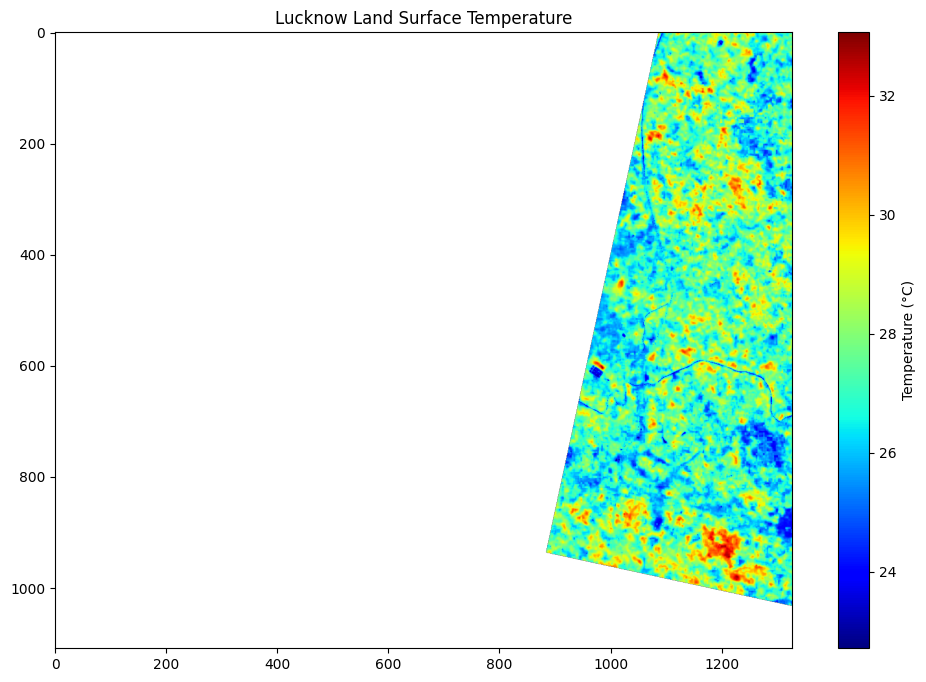

In [4]:
plt.figure(figsize=(12,8))
plt.imshow(lst, cmap='jet')
plt.colorbar(label='Temperature (°C)')
plt.title('Lucknow Land Surface Temperature')
plt.show()

# Identifying Heat Hotspots
In this step, areas with temperatures above 30°C are marked as heat hotspots. We also count the total number of hotspot pixels to understand the extent of high-temperature regions.

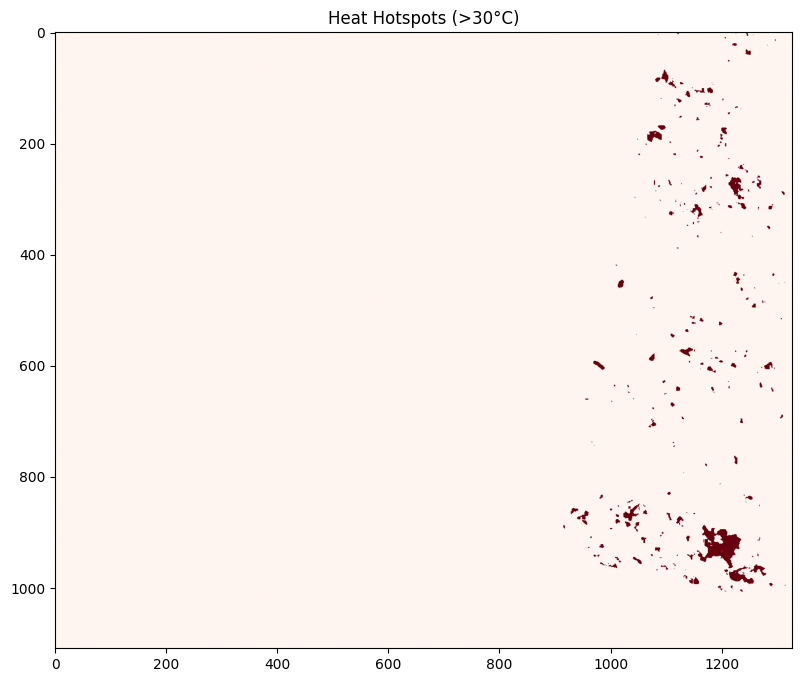

Hotspot Pixels: 10262


In [5]:

hotspots = lst > 30
plt.figure(figsize=(12,8))
plt.imshow(hotspots, cmap='Reds')
plt.title('Heat Hotspots (>30°C)')
plt.show()
print("Hotspot Pixels:", hotspots.sum())

# Area Classification
Here, we count the number of pixels belonging to cold, moderate, and hot temperature regions to get an overall picture of Lucknow's thermal conditions.

In [6]:
cold = np.sum(lst < 25)
moderate = np.sum((lst >= 25) & (lst < 30))
hot = np.sum(lst >= 30)
print("Cold Area Pixels:", cold)
print("Moderate Area Pixels:", moderate)
print("Hot Area Pixels:", hot)

Cold Area Pixels: 7219
Moderate Area Pixels: 325382
Hot Area Pixels: 10262


# Urban Heat Distribution
This pie chart shows the percentage of cold, moderate, and hot areas in Lucknow, providing a quick overview of the city's temperature distribution.

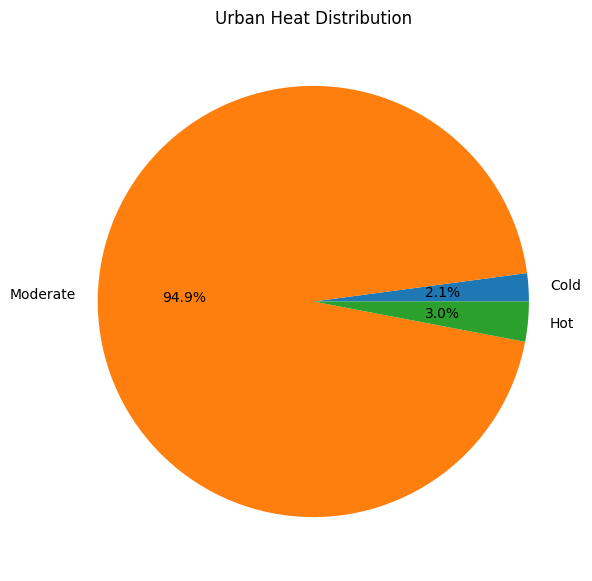

In [7]:
labels = ['Cold', 'Moderate', 'Hot']
sizes = [cold, moderate, hot]
plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title("Urban Heat Distribution")
plt.show()

# Preparing Data for Analysis
The temperature values are converted into a tabular format and stored in a DataFrame, making the data easier to analyze and use for machine learning.

In [8]:
temperature = lst.flatten()
df = pd.DataFrame({
    'temperature': temperature
})
df = df.dropna()
df.head()

,temperature
1085,27.592998
1086,27.234106
1087,26.827361
1088,26.379601
1089,25.962602


# Creating Heat Risk Labels
A heat risk label is assigned to each temperature value. Areas with temperatures above 30°C are marked as high-risk, while the remaining areas are marked as low-risk.

In [9]:
df['risk'] = np.where(
    df['temperature'] > 30,
    1,
    0
)
df.head()

,temperature,risk
1085,27.592998,0
1086,27.234106,0
1087,26.827361,0
1088,26.379601,0
1089,25.962602,0


# Training the Machine Learning Model
The dataset is split into training and testing sets, and a Random Forest model is trained to identify heat-risk areas based on temperature values.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['temperature']]
y = df['risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

Accuracy: 1.0


# Model Evaluation
This step helps us understand how well the model performs by comparing the predicted results with the actual heat-risk labels.

In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, pred)

print(cm)

print(classification_report(y_test, pred))

[[66573     0]
 [    0  2000]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66573
           1       1.00      1.00      1.00      2000

    accuracy                           1.00     68573
   macro avg       1.00      1.00      1.00     68573
weighted avg       1.00      1.00      1.00     68573



# Understanding Feature Importance
Here, we examine the importance of the temperature feature in predicting heat-risk areas. A higher value indicates a stronger influence on the model's decisions.

In [12]:
importance = model.feature_importances_

for i,v in enumerate(importance):
    print(f'Feature {i}: {v:.4f}')

Feature 0: 1.0000


# Saving the Trained Model
The trained Random Forest model is saved so it can be reused later without training it again.

In [13]:
import joblib

joblib.dump(model,'urban_heat_rf.pkl')

print("Model Saved Successfully")

Model Saved Successfully


# Urban Heat Severity Score
This score provides an overall measure of heat intensity in the study area by comparing the average temperature with the maximum recorded temperature.

In [14]:
valid_lst = lst[~np.isnan(lst)]

severity_score = (
    valid_lst.mean() /
    valid_lst.max()
) * 100

print(
    f"Urban Heat Severity Score: {severity_score:.2f}"
)

Urban Heat Severity Score: 82.87


# Checking Model Accuracy
Here, we measure how accurately the model can identify heat-risk and non-risk areas using the test data.

In [15]:
print(
    "Accuracy:",
    accuracy_score(y_test,pred)
)

Accuracy: 1.0


# Detailed Model Evaluation
The confusion matrix and classification report provide a deeper analysis of the model's performance, showing how accurately it classifies heat-risk and non-risk areas.

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm = confusion_matrix(y_test, pred)
print(cm)
print(classification_report(y_test, pred))

[[66573     0]
 [    0  2000]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66573
           1       1.00      1.00      1.00      2000

    accuracy                           1.00     68573
   macro avg       1.00      1.00      1.00     68573
weighted avg       1.00      1.00      1.00     68573



# Confusion Matrix Visualization
This visualization provides a clear view of the model's predictions, showing how many samples were correctly and incorrectly classified.

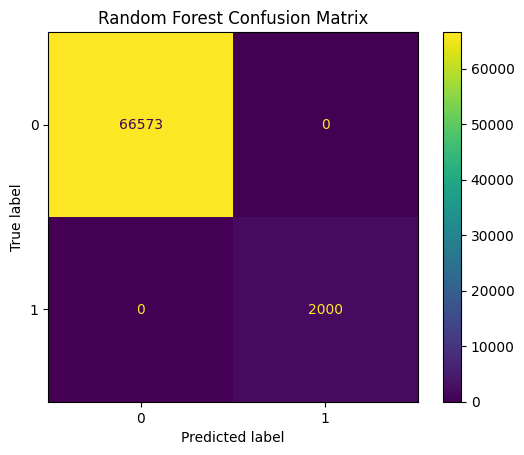

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")

plt.show()

# Saving the Trained Model
The trained Random Forest model is saved as a file so it can be reused later for heat-risk predictions without retraining.

In [18]:
import joblib

joblib.dump(
    model,
    "urban_heat_rf.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Measuring Overall Heat Intensity
Here, we calculate a heat severity score using the average and maximum temperatures to understand the overall thermal condition of Lucknow.

In [19]:
valid_lst = lst[~np.isnan(lst)]

severity_score = (
    valid_lst.mean() /
    valid_lst.max()
) * 100

print(
    f"Urban Heat Severity Score: {severity_score:.2f}"
)

Urban Heat Severity Score: 82.87


# Temperature Statistics
Here, we summarize the temperature data by calculating important statistics, which provide insights into the overall thermal conditions of the study area.

In [20]:
valid_lst = lst[~np.isnan(lst)]

print("Mean Temperature:", np.mean(valid_lst))
print("Median Temperature:", np.median(valid_lst))
print("Std Dev:", np.std(valid_lst))
print("Maximum:", np.max(valid_lst))
print("Minimum:", np.min(valid_lst))

Mean Temperature: 27.401062922333896
Median Temperature: 27.31613828000002
Std Dev: 1.268217767028476
Maximum: 33.06524792000005
Minimum: 22.715483360000007


# Temperature Summary
The following table summarizes the minimum, maximum, average, and variation in temperature across Lucknow for easy interpretation.

In [21]:
summary = pd.DataFrame({
    "Metric":[
        "Minimum Temperature",
        "Maximum Temperature",
        "Average Temperature",
        "Standard Deviation"
    ],
    "Value":[
        valid_lst.min(),
        valid_lst.max(),
        valid_lst.mean(),
        valid_lst.std()
    ]
})

summary

,Metric,Value
0,Minimum Temperature,22.715483
1,Maximum Temperature,33.065248
2,Average Temperature,27.401063
3,Standard Deviation,1.268218


# Saving the Summary Report
This step saves the temperature summary table as a CSV file for future reference and documentation.

In [22]:
summary.to_csv(
    "urban_heat_summary.csv",
    index=False
)

print("Summary Saved")

Summary Saved


# Visualizing Temperature Distribution
The histogram displays the frequency of different temperature values, giving a clear picture of the overall temperature pattern in Lucknow.

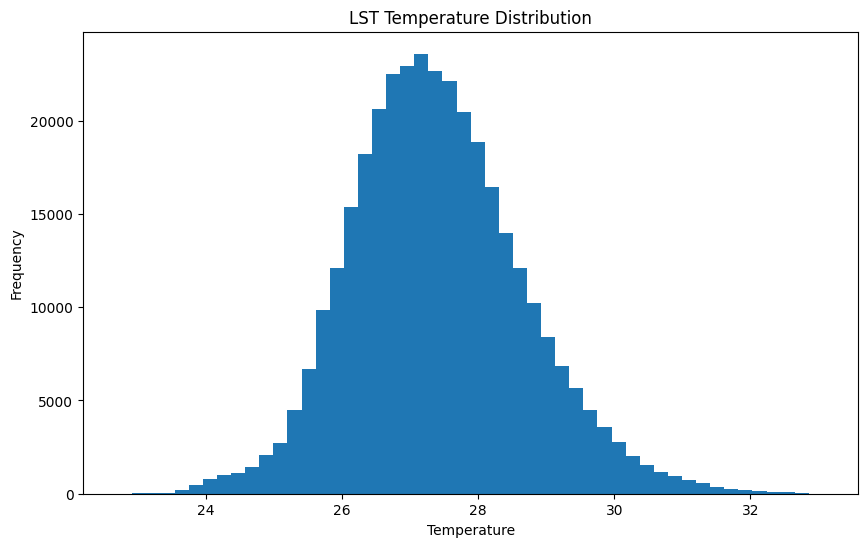

In [23]:
plt.figure(figsize=(10,6))

plt.hist(valid_lst.flatten(), bins=50)

plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("LST Temperature Distribution")

plt.show()

# Urban Heat Intensity Map
This map visualizes the intensity of land surface temperature across Lucknow, where brighter regions indicate higher temperatures and potential heat hotspots.

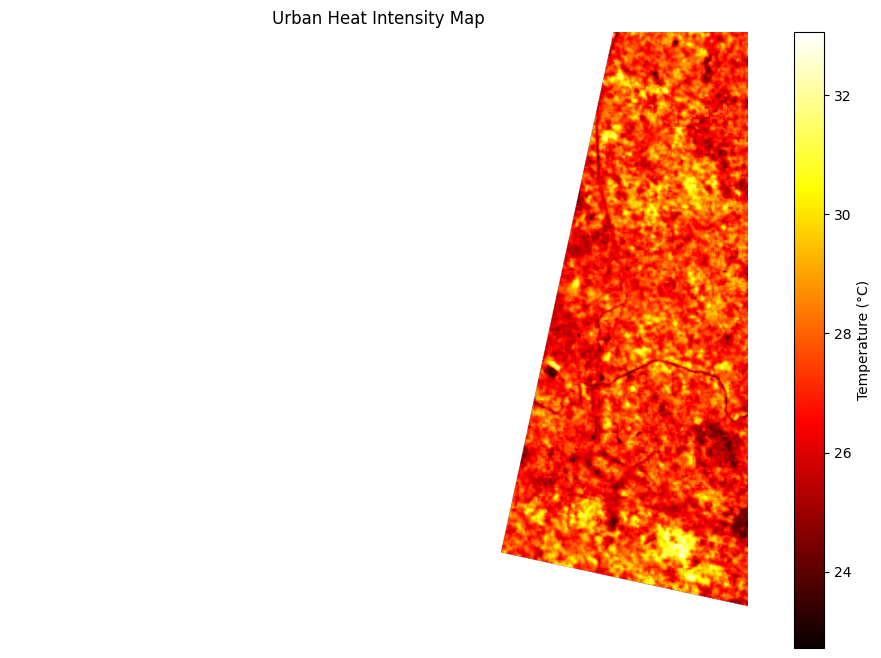

In [24]:
plt.figure(figsize=(12,8))

plt.imshow(lst, cmap='hot')

plt.colorbar(label='Temperature (°C)')

plt.title('Urban Heat Intensity Map')

plt.axis('off')

plt.show()

# Calculating Urban Heat Severity Score
This step computes an Urban Heat Severity Score using the average and maximum temperatures, providing a simple indicator of the overall heat intensity in the study area.

In [25]:
valid_lst = lst[~np.isnan(lst)]

severity_score = (
    valid_lst.mean() /
    valid_lst.max()
) * 100

print(
    f"Urban Heat Severity Score: {severity_score:.2f}"
)

Urban Heat Severity Score: 82.87


# Urban Heat Hotspot Mapping
Here, the top 10% hottest locations are identified and displayed on a map, helping us locate areas with extreme heat concentration.

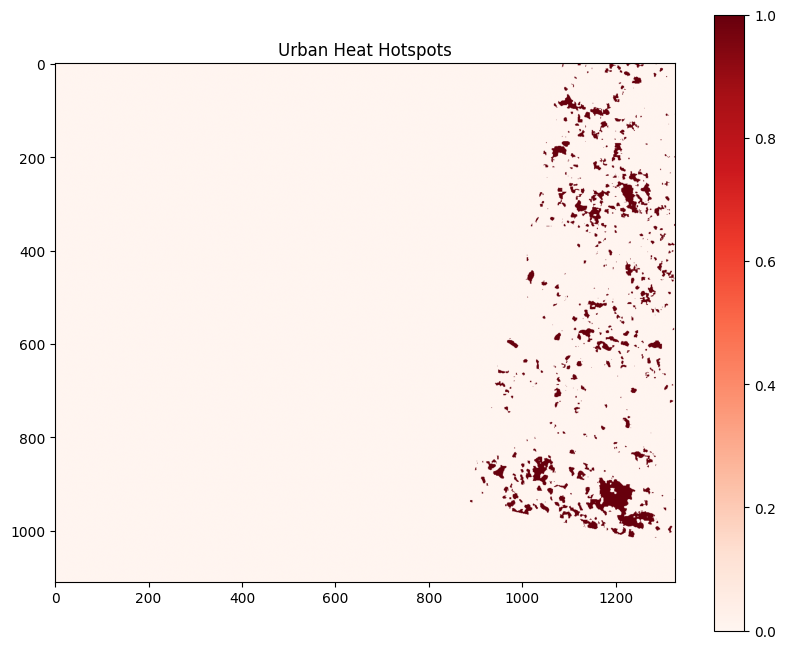

In [27]:
threshold = np.percentile(valid_lst, 90)

hotspots = np.where(lst > threshold, 1, 0)

plt.figure(figsize=(10,8))

plt.imshow(hotspots, cmap='Reds')

plt.title("Urban Heat Hotspots")

plt.colorbar()

plt.show()

# Mapping Heat Risk Zones
Here, temperature values are grouped into low, medium, and high-risk categories to identify areas that are more vulnerable to urban heat.

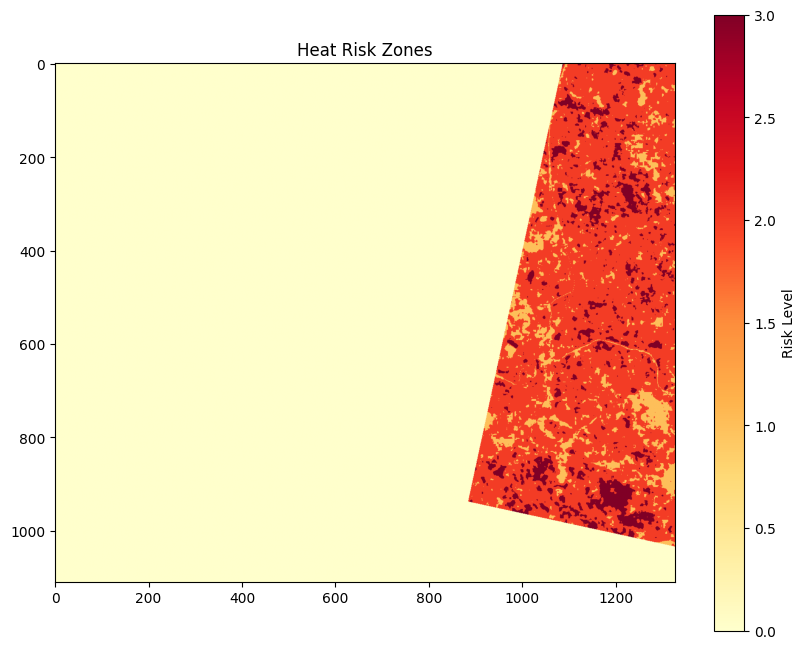

In [28]:
risk = np.zeros_like(lst)

risk[(lst >= 22) & (lst < 26)] = 1
risk[(lst >= 26) & (lst < 29)] = 2
risk[(lst >= 29)] = 3

plt.figure(figsize=(10,8))

plt.imshow(risk, cmap='YlOrRd')

plt.title("Heat Risk Zones")

plt.colorbar(label="Risk Level")

plt.show()

# Risk Zone Summary
Here, we count the total number of low, medium, and high-risk pixels to assess the overall heat risk distribution in Lucknow.

In [29]:
low_risk = np.sum(risk == 1)
medium_risk = np.sum(risk == 2)
high_risk = np.sum(risk == 3)

print("Low Risk Pixels:", low_risk)
print("Medium Risk Pixels:", medium_risk)
print("High Risk Pixels:", high_risk)

Low Risk Pixels: 41192
Medium Risk Pixels: 265047
High Risk Pixels: 36624


# Heat Hotspot Coverage
Here, we measure how much area falls within the identified heat hotspots and calculate its percentage relative to the entire study area.

In [30]:
total_pixels = hotspots.size

hot_pixels = np.sum(hotspots)

hot_percentage = (hot_pixels / total_pixels) * 100

print("Hotspot Pixels:", hot_pixels)
print("Hotspot Percentage:", hot_percentage)

Hotspot Pixels: 34203
Hotspot Percentage: 2.3241370359523335


# Visualizing Risk Levels
The pie chart helps compare the percentage of areas that fall under low, medium, and high heat-risk categories in Lucknow.

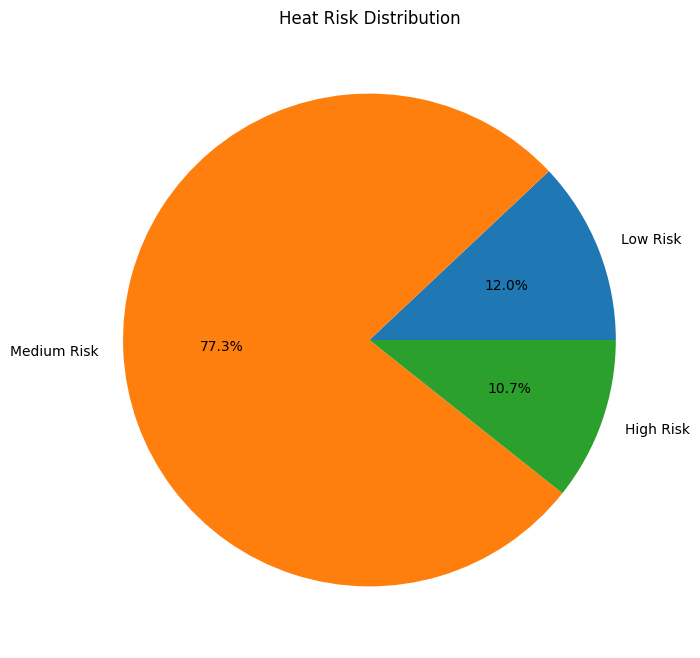

In [31]:
labels = ["Low Risk", "Medium Risk", "High Risk"]

sizes = [low_risk, medium_risk, high_risk]

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Heat Risk Distribution")

plt.show()

# Hotspot Coordinate Data
Here, the locations of detected heat hotspots are extracted and organized into a DataFrame, making them easier to analyze and export.

In [32]:

rows, cols = np.where(hotspots == 1)

hotspot_df = pd.DataFrame({
    "Row": rows,
    "Column": cols
})

hotspot_df.head()

,Row,Column
0,0,1117
1,0,1118
2,0,1119
3,0,1120
4,0,1121


# Reading Vegetation Data
Here, we load the NDVI dataset to analyze vegetation cover in Lucknow and get a quick overview of its value range.

In [33]:
with rasterio.open("Lucknow_NDVI.tif") as src:
    ndvi = src.read(1)

print("NDVI Shape:", ndvi.shape)
print("NDVI Min:", np.nanmin(ndvi))
print("NDVI Max:", np.nanmax(ndvi))

NDVI Shape: (1109, 1327)
NDVI Min: -0.092482045
NDVI Max: 0.4434761


# Loading NDBI Data
This step loads the NDBI (Normalized Difference Built-up Index) raster dataset and checks its dimensions and value range to analyze built-up areas in Lucknow.

In [34]:
with rasterio.open("Lucknow_NDBI.tif") as src:
    ndbi = src.read(1)

print("NDBI Shape:", ndbi.shape)
print("NDBI Min:", np.nanmin(ndbi))
print("NDBI Max:", np.nanmax(ndbi))

NDBI Shape: (1109, 1327)
NDBI Min: -0.31687522
NDBI Max: 0.16937989


# Comparing Dataset Sizes
Here, we check the shapes of the LST, NDVI, and NDBI datasets to make sure all raster layers align properly for further analysis.

In [35]:
print("LST Shape :", lst.shape)
print("NDVI Shape:", ndvi.shape)
print("NDBI Shape:", ndbi.shape)

LST Shape : (1109, 1327)
NDVI Shape: (1109, 1327)
NDBI Shape: (1109, 1327)


# Integrating Multiple Factors
Here, temperature, vegetation, and built-up area data are merged into one DataFrame to support further analysis and machine learning tasks.

In [36]:
data = pd.DataFrame({
    "LST": lst.flatten(),
    "NDVI": ndvi.flatten(),
    "NDBI": ndbi.flatten()
})

data.head()

,LST,NDVI,NDBI
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


# Cleaning the Dataset
Here, we remove any empty or incorrect values and prepare a clean dataset for further analysis and model development.

In [37]:
data = data.replace([np.inf, -np.inf], np.nan)

data = data.dropna()

print(data.shape)

data.head()

(342863, 3)


,LST,NDVI,NDBI
1085,27.592998,0.120678,0.014638
1086,27.234106,0.174370,-0.039334
1087,26.827361,0.166058,-0.000497
1088,26.379601,0.187880,-0.032085
1089,25.962602,0.201650,-0.066703


# Creating Heat Risk Categories
This step classifies each location into different heat risk levels based on its LST value, making it easier to identify low, moderate, and high-risk areas.

In [38]:
data["Heat_Risk"] = pd.cut(
    data["LST"],
    bins=[0,26,29,100],
    labels=[0,1,2]
)

data.head()

,LST,NDVI,NDBI,Heat_Risk
1085,27.592998,0.120678,0.014638,1
1086,27.234106,0.174370,-0.039334,1
1087,26.827361,0.166058,-0.000497,1
1088,26.379601,0.187880,-0.032085,1
1089,25.962602,0.201650,-0.066703,0


# Counting Risk Levels
Here, we calculate how many locations fall into each heat risk class, giving a quick overview of the overall heat risk pattern.

In [39]:
print(
    data["Heat_Risk"].value_counts()
)

Heat_Risk
1    265047
0     41192
2     36624
Name: count, dtype: int64


# Machine Learning-Based Heat Risk Classification
Here, a Random Forest model is trained using temperature, vegetation, and built-up area information to classify different heat risk zones and measure prediction accuracy.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = data[['LST', 'NDVI', 'NDBI']]
y = data['Heat_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 1.0


# Detailed Model Evaluation
Here, we evaluate how well the model predicts each heat risk level by analyzing important performance metrics like precision, recall, and F1-score.

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8238
           1       1.00      1.00      1.00     53010
           2       1.00      1.00      1.00      7325

    accuracy                           1.00     68573
   macro avg       1.00      1.00      1.00     68573
weighted avg       1.00      1.00      1.00     68573



# Understanding Important Factors
Here, we compare the importance of temperature, vegetation, and built-up area data to determine which feature plays the biggest role in heat risk prediction.

In [42]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

  Feature  Importance
0     LST     0.89346
2    NDBI     0.05557
1    NDVI     0.05097


# Visualizing Feature Importance
This bar chart compares the importance of LST, NDVI, and NDBI, helping us identify which factor contributes the most to heat risk prediction.

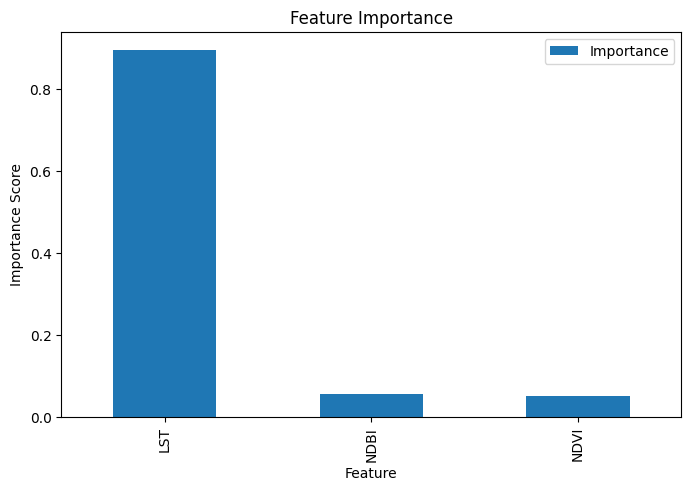

In [43]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

# Saving the Multi-Feature Model
This step saves the trained Random Forest model, allowing it to be reused later for heat risk prediction using LST, NDVI, and NDBI data.

In [44]:
import joblib

joblib.dump(
    rf_model,
    "urban_heat_multifeature_rf.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Visual Analysis of Model Performance
The confusion matrix visually compares actual and predicted heat risk classes, making it easier to evaluate the effectiveness of the model.

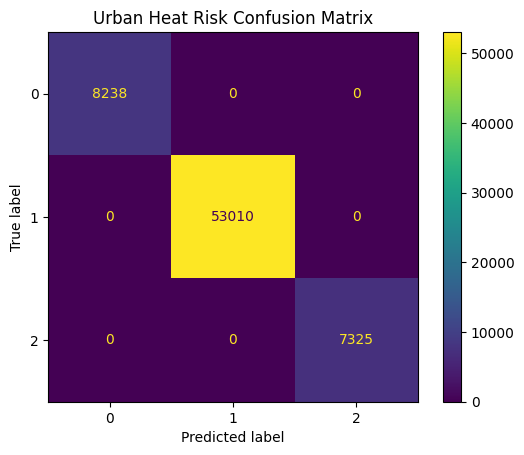

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Urban Heat Risk Confusion Matrix")
plt.show()

# Understanding Relationships Between Variables
Here, we examine how temperature, vegetation, and built-up areas influence each other by analyzing their correlation values.

In [46]:
corr = data[['LST','NDVI','NDBI']].corr()

print(corr)

           LST      NDVI     NDBI
LST   1.000000 -0.454444  0.58188
NDVI -0.454444  1.000000 -0.79517
NDBI  0.581880 -0.795170  1.00000


# Visualizing Variable Relationships
The correlation matrix helps us quickly understand how temperature, vegetation cover, and built-up areas are connected to each other.

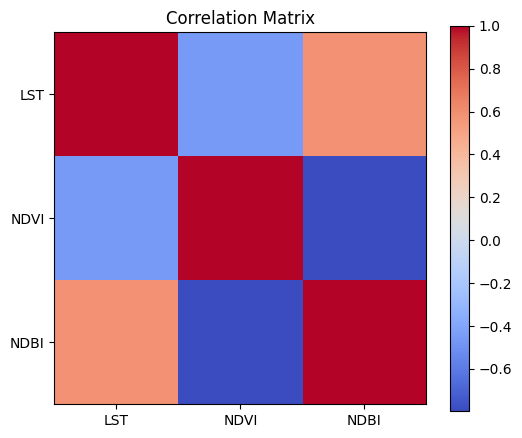

In [47]:
plt.figure(figsize=(6,5))

plt.imshow(
    corr,
    cmap='coolwarm'
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()